## Climate Change Modeling

## Problem Statement
- The goal is to predict and model various climate change indicators, such as temperature anomalies, precipitation patterns, and sea level changes, using historical climate data and machine learning techniques.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Loading a dataset

In [5]:
ccm = pd.read_csv('climate_nasa.csv')

In [6]:
ccm.head()

,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."


In [7]:
ccm.tail()

,date,likesCount,profileName,commentsCount,text
517,2022-12-22T17:21:37.000Z,0,9e17b1a6422032d47472f0216c73aafda7587e302eed5e...,NaN,One can only hope for a peak 😞
518,2022-12-22T17:19:51.000Z,1,48e55d898603a136aefc44771f248bffd67242583a462a...,5.0,what is the error margin for the temperature e...
519,2022-12-22T17:12:57.000Z,3,ca5d2611814cf8c9844ed06d9916d876d2dba94dac5ff2...,NaN,We all should volenteerly help in reducing Glo...
520,2022-12-22T17:01:12.000Z,1,a87c8aea74c9b97002b368d6143ce9c2809dcaec3103fb...,NaN,Sergio Yepes
521,2022-12-22T17:00:08.000Z,12,cc70f6c9dcc2637b1c5fd90046834612627c752b828cb4...,1.0,"We're experiencing severe, abnormal weather pa..."


## Domain Analysis
- Date: The date, time, and index number are provided when people comment on the site.
- LikeCount: Number of people who liked the comment.
- Profile: The Profile name of the person who posted the Climate change-related post.
- CommentsCount: Number of people who comment on the post.
- Text: Comment on the post. 

## Data Exploration and Visualization

## Descriptive Statistics

In [11]:
# Top 10 data in the dataset. 
ccm.head(10)

,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."
5,2022-09-15T17:10:57.000Z,4,191055fb869d185092abf1405f0b2f4abe73bcaa9beb85...,1.0,Excellent example...very relatable to the Gen ...
6,2022-09-07T17:31:25.000Z,10,a9117191b443a0494349d21508a3de7df675250b786612...,NaN,I am so proud of whoever created this content....
7,2022-09-07T18:07:53.000Z,1,39c3ec5a079b6b1a62577a1d13d4e8f894c5525575b85d...,21.0,Has the Earth ever had a concentration of over...
8,2022-09-07T22:45:56.000Z,0,1492464caa9b6757f6e740a6cc8f75a44614645e9f6c64...,NaN,"Yes, and not even half a cup later that poor s..."
9,2022-09-07T16:30:55.000Z,4,31fd4cfea1a56eb21ad6a86ce4ed94e6a15e654b3557bf...,8.0,Historical co2 data would make it an interesti...


In [12]:
# Last 10 data in the dataset
ccm.tail(10)

,date,likesCount,profileName,commentsCount,text
512,2022-12-22T17:54:41.000Z,0,a68d1872253b21c766d1c209443ef58f440c73b4ab79fb...,NaN,Also climate change involves severe weather of...
513,2022-12-22T17:51:29.000Z,0,5192227f29c1adef82bef5ff1f2a376ab3508ab33f72a7...,NaN,"With cold temperatures, ignoring change in alb..."
514,2022-12-22T17:46:40.000Z,1,9b258413c341e888a881b4df7c7885365c9041ee97834f...,2.0,Thank you.\nDo you happen to have a global tem...
515,2022-12-22T17:44:23.000Z,0,d58c7d89dbb5a839a2066ba44d7ffc94a53dd6f2a85795...,NaN,"""Ice On Fire"" documentary presents a through e..."
516,2022-12-22T17:41:51.000Z,6,3ba58dfe0f2baefb03214910335b4644ad2036a7f5d366...,NaN,Deniers will continue to be deniers because th...
517,2022-12-22T17:21:37.000Z,0,9e17b1a6422032d47472f0216c73aafda7587e302eed5e...,NaN,One can only hope for a peak 😞
518,2022-12-22T17:19:51.000Z,1,48e55d898603a136aefc44771f248bffd67242583a462a...,5.0,what is the error margin for the temperature e...
519,2022-12-22T17:12:57.000Z,3,ca5d2611814cf8c9844ed06d9916d876d2dba94dac5ff2...,NaN,We all should volenteerly help in reducing Glo...
520,2022-12-22T17:01:12.000Z,1,a87c8aea74c9b97002b368d6143ce9c2809dcaec3103fb...,NaN,Sergio Yepes
521,2022-12-22T17:00:08.000Z,12,cc70f6c9dcc2637b1c5fd90046834612627c752b828cb4...,1.0,"We're experiencing severe, abnormal weather pa..."


In [13]:
ccm.describe()

,likesCount,commentsCount
count,522.000000,244.000000
mean,4.720307,8.696721
std,12.053556,12.266176
min,0.000000,1.000000
25%,0.000000,2.000000
50%,1.000000,5.000000
75%,4.000000,10.000000
max,126.000000,93.000000


- There are a total of 522 likes on the comments, with an average of 5 likes per comment, a minimum of 0 likes, and a maximum of 126 likes.
- There are a total of 244 comments, with an average of 8 comments per post, a minimum of 1 comment, and a maximum of 93 comments on a single post.

In [15]:
ccm.describe(include='O')

,date,profileName,text
count,522,522,504
unique,522,483,503
top,2022-09-07T17:12:32.000Z,fbc7d1a96db0c682c8caaaf292d13527b1483b341da109...,The “greenhouse effect” is concerned with the ...
freq,1,3,2


- Each date are unique.
- There are a total of 522 users, of which 483 are unique, and 3 profile names are used frequently.
- A total of 504 texts have been posted, with 503 being unique and 2 texts being used frequently.

In [17]:
ccm.text.mode()

0    The “greenhouse effect” is concerned with the ...
Name: text, dtype: object

- This text have used frequently (The “greenhouse effect” is concerned with the ...)

In [19]:
ccm.profileName.mode()

0    0bc1bc50b627dd342e3a0498e0f8240c99d4daf267ebea...
1    460c1add92b947b25d86287b68758aa823c9b9e34e7a2b...
2    8aeea95ecbcc3b29e499cdeb08b4c25828bac77cdf313d...
3    b30b11aa9dbdae2cf34c9907f667ea8cfc36f92f7c9bec...
4    fbc7d1a96db0c682c8caaaf292d13527b1483b341da109...
Name: profileName, dtype: object

- The above profile name have used frequently.

In [21]:
likecount_range = ccm['likesCount'].max() - ccm['likesCount'].min()
commentsCount_range = ccm['commentsCount'].max() - ccm['commentsCount'].min()
print(f"Range of Like Count: {likecount_range}")
print(f"Range of Comment Count: {commentsCount_range}")

Range of Like Count: 126
Range of Comment Count: 92.0


In [22]:
ccm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB


In [23]:
ccm.isnull().sum()

date               0
likesCount         0
profileName        0
commentsCount    278
text              18
dtype: int64

- Comments Count have 278 null values.
- text have 18 null values.

In [25]:
ccm.duplicated().sum()

0

- There is no duplicate values.

## Visualization View

In [28]:
ccm['date'] = pd.to_datetime(ccm['date'])
ccm['year'] = ccm['date'].dt.year
ccm['month'] = ccm['date'].dt.month

In [29]:
ccm['date']

0     2022-09-07 17:12:32+00:00
1     2022-09-08 14:51:13+00:00
2     2022-09-07 17:19:41+00:00
3     2022-09-08 00:51:30+00:00
4     2022-09-07 19:06:20+00:00
                 ...           
517   2022-12-22 17:21:37+00:00
518   2022-12-22 17:19:51+00:00
519   2022-12-22 17:12:57+00:00
520   2022-12-22 17:01:12+00:00
521   2022-12-22 17:00:08+00:00
Name: date, Length: 522, dtype: datetime64[ns, UTC]

In [30]:
ccm['year']

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
517    2022
518    2022
519    2022
520    2022
521    2022
Name: year, Length: 522, dtype: int32

In [31]:
ccm['month']

0       9
1       9
2       9
3       9
4       9
       ..
517    12
518    12
519    12
520    12
521    12
Name: month, Length: 522, dtype: int32

In [32]:
ccm.columns

Index(['date', 'likesCount', 'profileName', 'commentsCount', 'text', 'year',
       'month'],
      dtype='object')

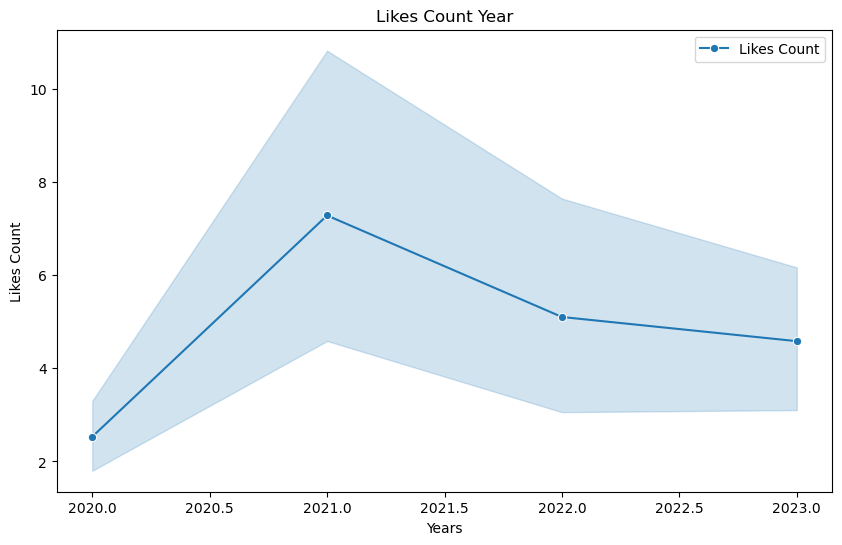

In [33]:
# Visualizations like count over the period
plt.figure(figsize=(10, 6))
sns.lineplot(data=ccm, x='year', y='likesCount', marker="o", label="Likes Count")
plt.title('Likes Count Year')
plt.xlabel('Years')
plt.ylabel('Likes Count')
plt.show()

- The likes count increased from 2020 to 2021 by near 8, and then fell after 2021 until 2022, slightly decreasing until 2023.

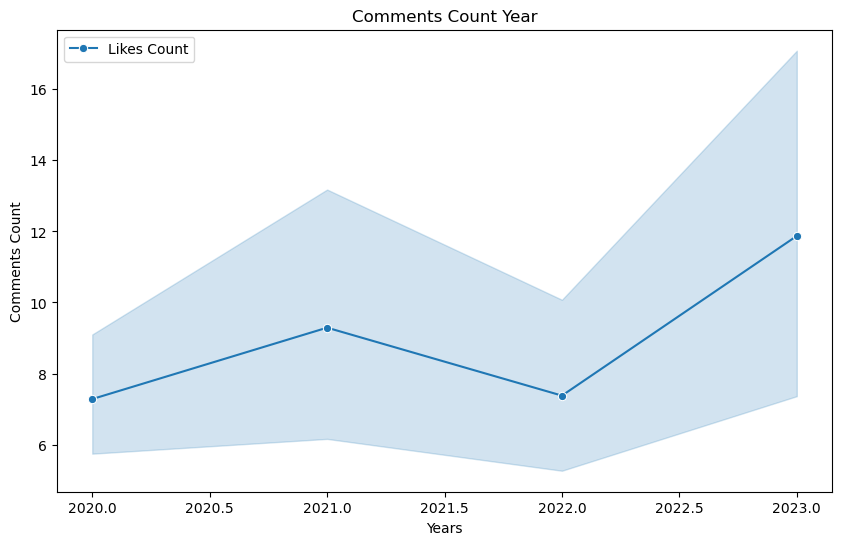

In [35]:
# Visualizations Comment count over the period
plt.figure(figsize=(10, 6))
sns.lineplot(data=ccm, x='year', y='commentsCount', marker="o", label="Likes Count")
plt.title('Comments Count Year')
plt.xlabel('Years')
plt.ylabel('Comments Count')
plt.show()

- The comment count slightly increased from 2021 to 2022, then decreased over the following year, and suddenly skyrocketed in 2023.

## Data Preprocessing and Feature Engineering

In [38]:
ccm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   date           522 non-null    datetime64[ns, UTC]
 1   likesCount     522 non-null    int64              
 2   profileName    522 non-null    object             
 3   commentsCount  244 non-null    float64            
 4   text           504 non-null    object             
 5   year           522 non-null    int32              
 6   month          522 non-null    int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(2), int64(1), object(2)
memory usage: 24.6+ KB


In [39]:
ccm.isnull().sum()

date               0
likesCount         0
profileName        0
commentsCount    278
text              18
year               0
month              0
dtype: int64

- CommentsCount and text have null values 278 and 18 respectively,

In [40]:
ccm.duplicated().sum()

0

In [41]:
# Handling the null values in comment column
avg_commentsCount = ccm['commentsCount'].mean()

In [42]:
ccm['commentsCount'] = ccm['commentsCount'].fillna(avg_commentsCount)

In [43]:
avg_text = ccm['text'].mode()[0]

In [44]:
avg_text

'The “greenhouse effect” is concerned with the infrared radiation given off by the earth. The sun’s radiation basically passes through the oxygen and nitrogen in the earth’s atmosphere and lands on the earth’s surface, where 70% of it is absorbed; 30% is reflected back into the atmosphere. Part of this radiation bounces off the greenhouse gases and returns to be absorbed by earth. The greenhouses gases (GHGs) are water vapor (H2O), carbon dioxide (CO2), nitrous oxide (NO2) and methane (CH4).\n\nHow long does CO2 remain in the atmosphere? This is a difficult question because there are several processes that remove carbon dioxide from the atmosphere. From 65% to 80% of the CO2 that is released into the air dissolves into the ocean over a period of 50-200 years. The rest is removed over several hundred thousand years. According to the IPCC Fourth Assessment Report, about 50% of CO2 increase will be removed from the atmosphere within 30 years, another 30% will be removed within a few centu

In [45]:
ccm['text'] = ccm['text'].fillna(avg_text)

In [46]:
ccm.isnull().sum()

date             0
likesCount       0
profileName      0
commentsCount    0
text             0
year             0
month            0
dtype: int64

In [47]:
ccm.head()

,date,likesCount,profileName,commentsCount,text,year,month
0,2022-09-07 17:12:32+00:00,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,8.696721,Neat comparison I have not heard it before.\n ...,2022,9
1,2022-09-08 14:51:13+00:00,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,8.696721,An excellent way to visualise the invisible! T...,2022,9
2,2022-09-07 17:19:41+00:00,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.000000,Does the CO2/ghg in the troposphere affect the...,2022,9
3,2022-09-08 00:51:30+00:00,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,8.696721,excellent post! I defo feel the difference - o...,2022,9
4,2022-09-07 19:06:20+00:00,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.000000,"Yes, and carbon dioxide does not harm the Eart...",2022,9


In [48]:
#dropping unnecessary columns 
ccm=ccm.drop(['date','commentsCount','profileName'],axis=1)

In [49]:
ccm.head()

,likesCount,text,year,month
0,2,Neat comparison I have not heard it before.\n ...,2022,9
1,0,An excellent way to visualise the invisible! T...,2022,9
2,1,Does the CO2/ghg in the troposphere affect the...,2022,9
3,4,excellent post! I defo feel the difference - o...,2022,9
4,16,"Yes, and carbon dioxide does not harm the Eart...",2022,9


In [50]:
#dropping unnecessary columns 
ccm=ccm.drop(['year','month'],axis=1)

In [51]:
ccm.head()

,likesCount,text
0,2,Neat comparison I have not heard it before.\n ...
1,0,An excellent way to visualise the invisible! T...
2,1,Does the CO2/ghg in the troposphere affect the...
3,4,excellent post! I defo feel the difference - o...
4,16,"Yes, and carbon dioxide does not harm the Eart..."


In [52]:
ccm.text.value_counts()

text
The “greenhouse effect” is concerned with the infrared radiation given off by the earth. The sun’s radiation basically passes through the oxygen and nitrogen in the earth’s atmosphere and lands on the earth’s surface, where 70% of it is absorbed; 30% is reflected back into the atmosphere. Part of this radiation bounces off the greenhouse gases and returns to be absorbed by earth. The greenhouses gases (GHGs) are water vapor (H2O), carbon dioxide (CO2), nitrous oxide (NO2) and methane (CH4).\n\nHow long does CO2 remain in the atmosphere? This is a difficult question because there are several processes that remove carbon dioxide from the atmosphere. From 65% to 80% of the CO2 that is released into the air dissolves into the ocean over a period of 50-200 years. The rest is removed over several hundred thousand years. According to the IPCC Fourth Assessment Report, about 50% of CO2 increase will be removed from the atmosphere within 30 years, another 30% will be removed within a few c

In [53]:
ccm.likesCount.value_counts()

likesCount
0      223
1       93
2       39
3       34
4       25
6       14
5        9
9        7
10       7
18       5
16       5
13       5
15       4
19       4
11       4
12       4
7        3
28       3
24       3
8        3
17       2
34       2
37       2
43       2
21       2
22       2
14       2
110      1
120      1
46       1
55       1
38       1
126      1
62       1
40       1
20       1
27       1
54       1
33       1
26       1
32       1
Name: count, dtype: int64

## Clean Text Data

In [106]:
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from textblob import TextBlob
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # Remove URLs
    text = re.sub(r'@\w+|\#', '', text)  # Remove mentions and hashtags
    text = re.sub(r'[^A-Za-z\s]', '', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

In [108]:
ccm['cleaned_text'] = ccm['text'].astype(str).apply(clean_text)

In [114]:
ccm['cleaned_text']

0      neat comparison heard say like disco ball ener...
1               excellent way visualise invisible thanks
2      does coghg troposphere affect stratosphere war...
3      excellent post defo feel difference drink make...
4      yes carbon dioxide does harm earth like people...
                             ...                        
517                                            hope peak
518       error margin temperature estimations years ago
519            volenteerly help reducing globall warming
520                                         sergio yepes
521    experiencing severe abnormal weather patterns ...
Name: cleaned_text, Length: 522, dtype: object

## Word Cloud

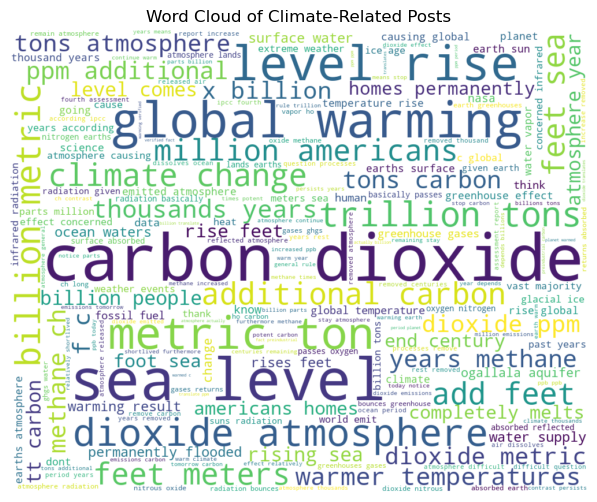

In [177]:
text_combined = ' '.join(ccm['cleaned_text'])
wordcloud = WordCloud(width=1000, height=800, background_color='white').generate(text_combined)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Climate-Related Posts")
plt.show()


## Sentiment Analysis

In [122]:
def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [124]:
ccm['sentiment'] = ccm['cleaned_text'].apply(get_sentiment)

In [126]:
ccm['sentiment']

0       Neutral
1      Positive
2       Neutral
3      Positive
4      Negative
         ...   
517     Neutral
518     Neutral
519     Neutral
520     Neutral
521    Negative
Name: sentiment, Length: 522, dtype: object

- Provide positive, negative, and neutral based on the individual comments.

## Visualize Sentiment Distribution

<Figure size 800x500 with 0 Axes>

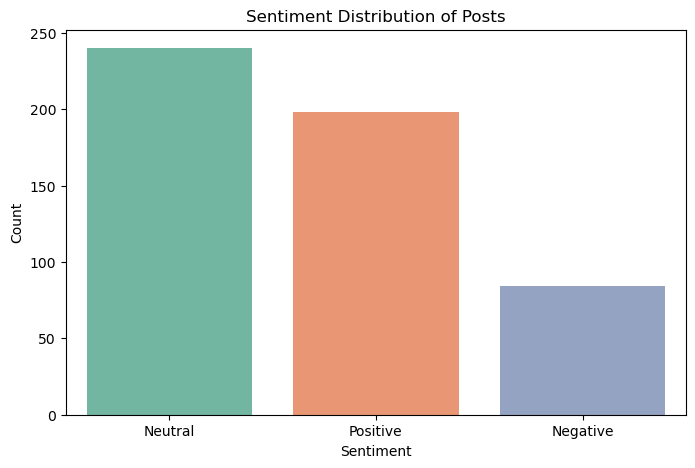

In [130]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ccm, x='sentiment', palette='Set2')
plt.title("Sentiment Distribution of Posts")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

- Neutral sentiment has the highest count, slightly above 240.
- Positive sentiment follows, with a count just below 200.
- Negative sentiment has the lowest count, around 80.
- This suggests that most posts are neutral in tone, followed by positive ones, and relatively fewer express negative sentiments.

## Modeling with LDA

In [138]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(ccm['cleaned_text'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)


LatentDirichletAllocation(n_components=5, random_state=42)

## Display Topics

In [140]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx+1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print()

display_topics(lda, vectorizer.get_feature_names_out(), 10)

Topic 1:
climate change planet people nasa temperature time global know just

Topic 2:
climate change warming global ice need years age stop going

Topic 3:
getting climate world line power fight scientists like just day

Topic 4:
carbon atmosphere dioxide feet sea level water rise billion tons

Topic 5:
earth years people sun climate change just thanks heat nasa



## Predictive Modeling - Sentiment Classification

In [166]:
##Convert text to TF-IDF features
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(ccm['cleaned_text'])
y = ccm['sentiment']


In [146]:
y_encoded = y.map({'Negative': 0, 'Neutral': 1, 'Positive': 2})

## Model Creation

In [150]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': MultinomialNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}


In [156]:
for name, model in models.items():
    print(f"\n{name}:")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Logistic Regression:
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.74      0.88      0.81        59
           2       0.66      0.68      0.67        34

    accuracy                           0.71       105
   macro avg       0.47      0.52      0.49       105
weighted avg       0.63      0.71      0.67       105

Confusion Matrix:
 [[ 0  7  5]
 [ 0 52  7]
 [ 0 11 23]]

Random Forest:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.17      0.29        12
           1       0.77      0.98      0.87        59
           2       0.82      0.68      0.74        34

    accuracy                           0.79       105
   macro avg       0.86      0.61      0.63       105
weighted avg       0.81      0.79      0.76       105

Confusion Matrix:
 [[ 2  6  4]
 [ 0 58  1]
 [ 0 11 23]]

Gradient Boosting:
Classification Repor

- Random Forest provides the highest accuracy score of 79%, compared to other models. Although Linear Regression and Gradient Boosting have performance scores close to that of Random Forest, they are slightly lower which are 71 and 74 percent.

## Save Cleaned and Annotated Data

In [168]:
ccm.to_csv("cleaned_climate_nasa_sentiment.csv", index=False)